# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

How can a used car business optimize profit on used cars? In this study, our goal is to use regression techniques on vehicle features to identify which features affect the sales price of a used car. By analyzing the relationship between price and attributes like age, mileage, and brand, we can identify the key drivers of value and provide actionable recommendations to optimize pricing and inventory.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

The dataset contains approximately 426,000 used car listings with features such as price, year, manufacturer, model, condition, odometer, fuel type, transmission, and location. Initial exploration will focus on understanding data types, distributions, and potential data quality issues such as missing values, duplicates, and outliers.For example, extremely high or low prices, year of car less than 2000, mileage is greater than 300 miles.

We will also examine relationships between variables - price vs. age or mileage to identify early patterns that may influence modeling decisions.

STEPS TO ANALYZE DATA

STEP 1 Examine dataset structure (rows, columns, data types)
*   Load the dataset and inspect its shape
*   Display the first few rows (.head()) to understand what each column represents
*   Check data types using .info() to confirm numerical vs. categorical variables

In [ ]:
# Load the dataset
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
vehicles = pd.read_csv('/content/data/vehicles.csv')
vehicles.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [ ]:
# Inspect its shape
vehicles.shape

# Result: 426,880 rows - individual car listings (data points), 18 columns - features/variables describing each car

(426880, 18)

In [ ]:
# View the first few rows
vehicles.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [ ]:
# Check column names
vehicles.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

In [ ]:
# Check data types
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

STEP 2 Identify data quality issues (missing values,  duplicates, invalid entries, outliers, categorical consistency)

*   Check for missing values using .isnull().sum() and calculate percentages

*   Decide which columns have significant missing values that may need removal or filled in with the mode.

*   Check for duplicate rows using .duplicated() and remove them - none found.

*   Look for invalid or unrealistic values. For example, price ≤ 0, mileage extremely high, year in the future. Filter out these records during data cleaning step.

In [ ]:
# Check for missing values
vehicles.isnull().sum().sort_values(ascending=False)


,0
size,306361
cylinders,177678
condition,174104
VIN,161042
drive,130567
paint_color,130203
type,92858
manufacturer,17646
title_status,8242
model,5277


In [ ]:
# Missing values in percentage
(vehicles.isnull().mean() * 100).sort_values(ascending=False)


,0
size,71.767476
cylinders,41.622470
condition,40.785232
VIN,37.725356
drive,30.586347
paint_color,30.501078
type,21.752717
manufacturer,4.133714
title_status,1.930753
model,1.236179


**Analysis**

Drop these columns (in Data Prepartion step):

*   VIN (38%) - not useful for modeling
*   size (71%) - too much missing data

Keep these columns with missing values as they are valuable for price prediction:

*   cylinders (41%)
*   condition (39%)
*   drive (31%)
*   paint_color (30%)
*   type (22%)

In [ ]:
# Identify duplicate rows - none
vehicles.duplicated().sum()

np.int64(0)

In [ ]:
# Inspect and filter out unrealistic data - price is less than 0
# vehicles[vehicles['price'] <= 0] # 32,895 rows price is less than 0
print("Invalid price rows:", (vehicles['price'] <= 0).sum())

Invalid price rows: 32895


In [ ]:
# Inspect and filter out unrealistic data - odometer greater than 250,000 due to liability risk
vehicles[vehicles['odometer'] > 250000] #7080 rows

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
138,7304785580,auburn,4000,2006.0,jeep,grand cherokee laredo,good,6 cylinders,gas,281000.0,clean,automatic,NaN,rwd,mid-size,SUV,black,al
280,7315849335,birmingham,987654321,1960.0,chevrolet,NaN,NaN,NaN,gas,999999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
315,7315506908,birmingham,4950,2001.0,toyota,4runner limited,NaN,6 cylinders,gas,266000.0,clean,automatic,NaN,rwd,NaN,SUV,white,al
336,7315355524,birmingham,3500,1998.0,jeep,cherokee,NaN,6 cylinders,gas,273000.0,clean,automatic,NaN,4wd,NaN,SUV,white,al
342,7315294251,birmingham,1200,2005.0,chevrolet,impala,fair,4 cylinders,gas,256806.0,clean,automatic,NaN,fwd,mid-size,sedan,blue,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426643,7307059015,wyoming,4200,2001.0,toyota,sequoia,fair,8 cylinders,gas,287000.0,clean,automatic,NaN,4wd,full-size,SUV,white,wy
426644,7307051186,wyoming,1600,1998.0,ram,1500,fair,8 cylinders,gas,255747.0,clean,automatic,NaN,4wd,NaN,pickup,NaN,wy
426671,7306463286,wyoming,9900,2005.0,chevrolet,2500 ls,NaN,NaN,diesel,291137.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,wy
426690,7305718110,wyoming,6500,2002.0,ford,f 350,NaN,NaN,diesel,295000.0,clean,manual,NaN,NaN,NaN,NaN,NaN,wy


In [ ]:
# Inpsect and filter out unrealistic data - year greater than 2026 or less than year 2000
vehicles[vehicles['year'] > 2026] # no rows
vehicles[vehicles['year'] < 2000] # 25,250 rows


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
37,7316130053,auburn,4500,1992.0,jeep,cherokee,excellent,6 cylinders,gas,192000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,al
101,7309160821,auburn,12990,1968.0,volvo,NaN,NaN,NaN,gas,99999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
137,7305082143,auburn,2500,1966.0,NaN,1966 C-30 1 ton,good,6 cylinders,gas,47000.0,clean,manual,NaN,rwd,full-size,pickup,brown,al
185,7316853268,birmingham,1800,1998.0,toyota,rav4,good,4 cylinders,gas,240537.0,clean,manual,NaN,NaN,NaN,NaN,green,al
193,7316734951,birmingham,5900,1998.0,ford,f150,excellent,8 cylinders,gas,214000.0,clean,automatic,NaN,NaN,full-size,truck,red,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426813,7302839732,wyoming,1000,1998.0,ford,explorer,NaN,6 cylinders,gas,190000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,wy
426815,7302634053,wyoming,5000,1996.0,NaN,96 Suburban,excellent,8 cylinders,gas,170000.0,clean,automatic,NaN,NaN,NaN,SUV,brown,wy
426831,7302384818,wyoming,9800,1985.0,nissan,300zx coupe with t-tops,like new,6 cylinders,gas,115000.0,clean,automatic,NaN,rwd,sub-compact,hatchback,red,wy
426833,7302338378,wyoming,6800,1997.0,jaguar,xk8 convertible,good,8 cylinders,gas,69550.0,clean,automatic,SAJGX2749VCOO8376,rwd,compact,convertible,white,wy


In [ ]:
# Inpsect and filter out unrealistic data - condition is salvage
vehicles[vehicles['condition'] == 'salvage'] # 601 rows

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
3326,7308530084,huntsville / decatur,800,2007.0,ford,freestyle,salvage,6 cylinders,gas,142862.0,clean,automatic,NaN,fwd,full-size,wagon,grey,al
5086,7316470951,anchorage / mat-su,2500,1999.0,chevrolet,k3500,salvage,8 cylinders,gas,178000.0,clean,automatic,1GCHK33R0XF081095,4wd,full-size,pickup,grey,ak
5262,7315604128,anchorage / mat-su,800,1986.0,ford,f-350 super duty,salvage,NaN,gas,200000.0,clean,automatic,NaN,4wd,full-size,truck,NaN,ak
5609,7314408746,anchorage / mat-su,1000,2000.0,jeep,cherokee classic,salvage,6 cylinders,gas,230000.0,clean,automatic,NaN,rwd,NaN,SUV,white,ak
5752,7313705602,anchorage / mat-su,15000,1964.0,ford,mustang,salvage,6 cylinders,gas,67000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,ak
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425354,7312294553,sheboygan,1150,1987.0,NaN,1987 Bronco II,salvage,6 cylinders,gas,134584.0,clean,manual,NaN,4wd,mid-size,offroad,red,wi
425544,7317071710,wausau,700,1998.0,toyota,camry xle,salvage,6 cylinders,gas,321132.0,clean,automatic,NaN,fwd,compact,sedan,grey,wi
426106,7305894766,wausau,850,1987.0,ram,NaN,salvage,NaN,gas,9999999.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,wi
426170,7304251093,wausau,500,2004.0,pontiac,bonneville sle,salvage,6 cylinders,gas,195000.0,clean,automatic,NaN,fwd,NaN,NaN,red,wi


In [ ]:
# Inpsect and filter out unrealistic data - title status is salvage, missing or parts only
# results - 4880 rows
vehicles[vehicles['title_status'].isin(['salvage', 'missing', 'parts only'])]

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
491,7313856690,birmingham,14700,2015.0,honda,cr-v ex-l,excellent,4 cylinders,gas,70672.0,salvage,automatic,2HKRM4H77FH677160,4wd,compact,SUV,brown,al
599,7313167064,birmingham,1500,2004.0,chevrolet,colorado,fair,4 cylinders,gas,150000.0,missing,automatic,NaN,rwd,NaN,truck,black,al
1016,7309558028,birmingham,12500,1946.0,NaN,AutoCar flatbed truck,fair,6 cylinders,gas,123.0,missing,manual,906419252,NaN,NaN,NaN,NaN,al
1091,7308738418,birmingham,4000,1958.0,ford,pick up,good,8 cylinders,gas,110000.0,missing,automatic,NaN,4wd,NaN,NaN,black,al
1391,7305668545,birmingham,2950,1963.0,chevrolet,corvair convertible,fair,4 cylinders,gas,1164.0,missing,manual,NaN,rwd,compact,convertible,blue,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426647,7307040086,wyoming,7550,2017.0,chevrolet,trax turbo,NaN,4 cylinders,gas,27386.0,salvage,automatic,NaN,fwd,NaN,SUV,blue,wy
426648,7307026251,wyoming,5950,2016.0,volkswagen,jetta tsi,NaN,4 cylinders,gas,72467.0,salvage,automatic,NaN,fwd,NaN,sedan,blue,wy
426709,7305590558,wyoming,9000,2015.0,jeep,wrangler unlimited,salvage,6 cylinders,gas,73000.0,salvage,automatic,NaN,4wd,NaN,SUV,black,wy
426789,7303206312,wyoming,11000,2017.0,NaN,ATI,like new,other,other,1.0,missing,other,NaN,NaN,NaN,NaN,brown,wy


STEP 3 Analyze distribution of key variables, including price

*   Generate summary statistics using .describe()
*   Plot histograms or density plots for price to check skewness
*   Use boxplots to identify outliers in price and other numerical features






In [ ]:
# Summary statistics
vehicles.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


<Axes: >

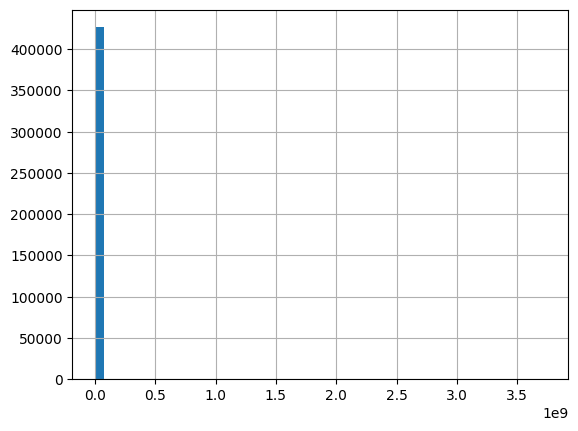

In [ ]:
# Histogram of price

vehicles['price'].hist(bins=50)

<Axes: >

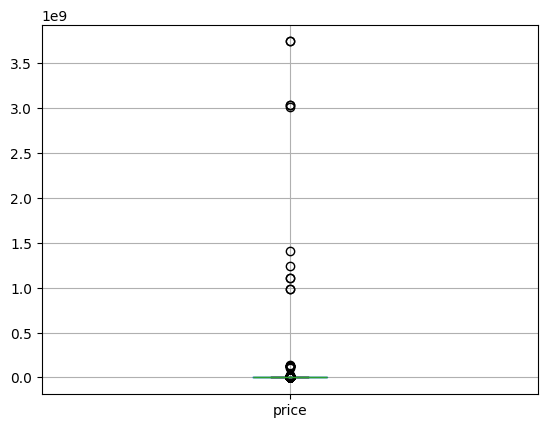

In [ ]:
# Boxplot of outliers
vehicles.boxplot(column='price')

STEP 4 Explore relationships between features and price

*   Create scatter plots - price vs. mileage and price vs. year
*   Compute correlations for numerical variables (.corr())
*   Use boxplots to compare price across categorical variables - condition and fuel type
*   Identify which variables show strong or weak relationships with price

<Axes: xlabel='year', ylabel='price'>

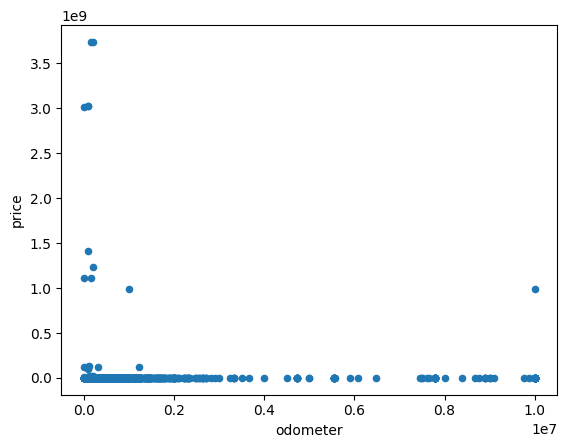

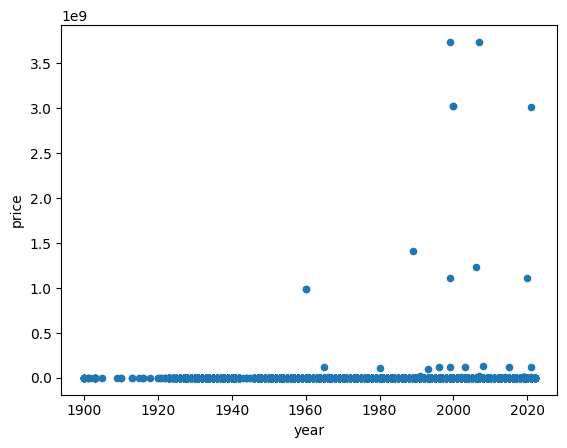

In [ ]:
# Create scatter plots

vehicles.plot.scatter(x='odometer', y='price')
vehicles.plot.scatter(x='year', y='price')

In [ ]:
# Correlation matrix

vehicles.corr(numeric_only=True)

,id,price,year,odometer
id,1.000000,-0.002779,-0.059040,0.010721
price,-0.002779,1.000000,-0.004925,0.010032
year,-0.059040,-0.004925,1.000000,-0.157215
odometer,0.010721,0.010032,-0.157215,1.000000


<Axes: title={'center': 'price'}, xlabel='condition'>

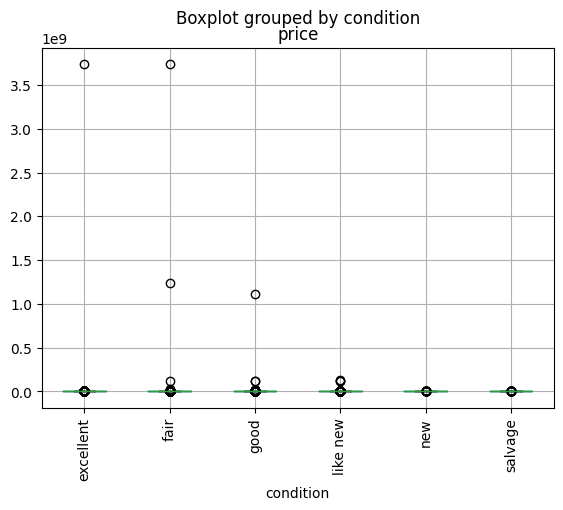

In [ ]:
# Boxplot for categorical variables

vehicles.boxplot(column='price', by='condition', rot=90)

STEP 5 Review categorical variables for consistency and distribution
*   List unique values for each categorical column (.unique()) and check for inconsistent labels to standardize them at next step
*   Identify rare categories. Count frequencies using .value_counts() to understand common vs rare categories
*   Identify rare categories for grouping.








In [ ]:
# List unique values for each categorical column (.unique())
# Unique values

# vehicles['fuel'].unique()
# vehicles['transmission'].unique()
# vehicles['condition'].unique()
# vehicles['drive'].unique()
# vehicles['type'].unique()
# vehicles['manufacturer'].unique()
# vehicles['model'].unique()
# vehicles['cylinders'].unique()
# vehicles['title_status'].unique()
# vehicles['paint_color'].unique()
# vehicles['state'].unique()
categorical_cols = [
    'fuel', 'transmission', 'condition', 'drive', 'type',
    'manufacturer', 'model', 'cylinders', 'title_status',
    'paint_color', 'state'
]

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(vehicles[col].unique())


Column: fuel
[nan 'gas' 'other' 'diesel' 'hybrid' 'electric']

Column: transmission
[nan 'other' 'automatic' 'manual']

Column: condition
[nan 'good' 'excellent' 'fair' 'like new' 'new' 'salvage']

Column: drive
[nan 'rwd' '4wd' 'fwd']

Column: type
[nan 'pickup' 'truck' 'other' 'coupe' 'SUV' 'hatchback' 'mini-van' 'sedan'
 'offroad' 'bus' 'van' 'convertible' 'wagon']

Column: manufacturer
[nan 'gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac' 'honda' 'dodge' 'lexus' 'jaguar' 'buick' 'chrysler' 'volvo'
 'audi' 'infiniti' 'lincoln' 'alfa-romeo' 'subaru' 'acura' 'hyundai'
 'mercedes-benz' 'bmw' 'mitsubishi' 'volkswagen' 'porsche' 'kia' 'rover'
 'ferrari' 'mini' 'pontiac' 'fiat' 'tesla' 'saturn' 'mercury'
 'harley-davidson' 'datsun' 'aston-martin' 'land rover' 'morgan']

Column: model
[nan 'sierra 1500 crew cab slt' 'silverado 1500' ... 'gand wagoneer'
 '96 Suburban' 'Paige Glenbrook Touring']

Column: cylinders
[nan '8 cylinders' '6 cylinders' '4 cylinders' '5 

In [ ]:
# Review frequency counts/distributions

# vehicles['fuel'].value_counts()
# vehicles['transmission'].value_counts()
# vehicles['condition'].value_counts()
# vehicles['drive'].value_counts()
# vehicles['type'].value_counts()
# vehicles['manufacturer'].value_counts()
# vehicles['model'].value_counts()
# vehicles['cylinders'].value_counts()
# vehicles['paint_color'].value_counts()
# vehicles['state'].value_counts()

cols = [
    'fuel', 'transmission', 'condition', 'drive', 'type',
    'manufacturer', 'model', 'cylinders', 'paint_color', 'state'
]

for col in cols:
    print(f"\nColumn: {col}")
    print(vehicles[col].value_counts())

# Summary of unique counts
vehicles[cols].nunique()


Column: fuel
fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64

Column: transmission
transmission
automatic    336524
other         62682
manual        25118
Name: count, dtype: int64

Column: condition
condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

Column: drive
drive
4wd    131904
fwd    105517
rwd     58892
Name: count, dtype: int64

Column: type
type
sedan          87056
SUV            77284
pickup         43510
truck          35279
other          22110
coupe          19204
hatchback      16598
wagon          10751
van             8548
convertible     7731
mini-van        4825
offroad          609
bus              517
Name: count, dtype: int64

Column: manufacturer
manufacturer
ford               70985
chevrolet          55064
toyota             34202
honda              21269
nissan             190

,0
fuel,5
transmission,3
condition,6
drive,3
type,13
manufacturer,42
model,29649
cylinders,8
paint_color,12
state,51


In [ ]:
# Identify rare categories for grouping

col = 'type'

freq = vehicles[col].value_counts(normalize=True)  # percentage
rare = freq[freq < 0.01]  # less than 1%

print(rare)

type
offroad    0.001823
bus        0.001548
Name: proportion, dtype: float64


STEP 6 Assess dataset relevance to business objective
*   Evaluate whether key factors influencing price (e.g. age, mileage, brand, condition) are present
*   Identify any missing variables that could improve analysis (e.g., accident history)
*   Determine if the dataset size and feature set are sufficient for building a reliable pricing model
*   Form initial hypotheses about what drives price based on early exploration







In [ ]:
# Compare price across key categorical variables

# Condition
vehicles.groupby('condition')['price'].median().sort_values(ascending=False)


,price
condition,
good,19995.0
new,15900.0
like new,13950.0
excellent,10995.0
fair,2800.0
salvage,1800.0


In [ ]:
# Manufacturer (top 10 for readability)
vehicles.groupby('manufacturer')['price'].median().sort_values(ascending=False).head(10)


,price
manufacturer,
ferrari,98900.0
aston-martin,46997.5
tesla,37990.0
alfa-romeo,29590.0
porsche,28850.0
jaguar,28590.0
ram,27435.5
rover,24990.0
audi,23551.0


In [ ]:
# Type
vehicles.groupby('type')['price'].median().sort_values(ascending=False)


,price
type,
pickup,27990.0
other,25590.0
truck,20999.0
coupe,18516.5
convertible,15000.0
van,14995.0
hatchback,13950.0
SUV,13295.0
offroad,12500.0


In [ ]:
# Fuel
vehicles.groupby('fuel')['price'].median().sort_values(ascending=False)



,price
fuel,
diesel,27990.0
other,25990.0
electric,22544.5
gas,11998.0
hybrid,11995.0


In [ ]:
# Check feature completeness for modeling
# Focus on key modeling features
key_features = ['price', 'year','cylinders', 'odometer', 'VIN', 'manufacturer', 'condition', 'fuel', 'transmission']

vehicles[key_features].isnull().mean() * 100

,0
price,0.000000
year,0.282281
cylinders,41.622470
odometer,1.030735
VIN,37.725356
manufacturer,4.133714
condition,40.785232
fuel,0.705819
transmission,0.598763


In [ ]:
# Does price decrease with mileage?
vehicles[['price', 'odometer']].corr()

,price,odometer
price,1.000000,0.010032
odometer,0.010032,1.000000


**Analysis**

The dataset contains key variables relevant to determining used car prices, including vehicle age (derived from year), odometer, manufacturer, model, condition and vehicle type. These features align well with factors that consumers typically consider when evaluating used cars.

However, some important variables which can influence price are not included, such as accident history, maintenance records, number of previous owners, and trim. The absence of these variables may limit the ability to fully capture all drivers of price. Overall, the dataset is sufficient and contains relevant features to support a reliable analysis and predictive modeling of used car prices, despite some missing contextual variables.

Preliminary exploration suggests that newer vehicles (lower vehicle age), lower mileage, better condition, and certain manufacturers are associated with higher prices. Additionally, vehicle type (SUVs and trucks) may influence pricing patterns.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [ ]:
# Data Preparation

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [ ]:
# Make a back up copy and a working copy so original dataset is preserved
vehicles_backup = vehicles.copy()
# Working copy
df = vehicles.copy()

In [ ]:
# Step 1 Remove invalid/unrealistic values
# Drop columns that are not useful or have too many missing values
df = df.drop(columns=['id', 'VIN', 'size', 'paint_color','region', 'id'], errors='ignore')

In [ ]:
df['price'].describe()

,price
count,4.268800e+05
mean,7.519903e+04
std,1.218228e+07
min,0.000000e+00
25%,5.900000e+03
50%,1.395000e+04
75%,2.648575e+04
max,3.736929e+09


In [ ]:
# Remove invalid or unrealistic values
df = df[
    (df['price'] >= 1000) & (df['price'] <= 100000) &
    (df['year'] >= 2000) & (df['year'] <= 2026) &
    (df['odometer'] > 0) & (df['odometer'] <= 250000) &
    (df['condition'] != 'salvage') &
    (~df['title_status'].isin(['salvage', 'missing', 'parts only']))
]

In [ ]:
# View results after removing unrealistic values
df.shape # 359,403 rows remaining after filtering, 17 columns after dropping and adding features
print(df.columns.tolist())

['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'state']


In [ ]:
# Step 2 Clean categorical text, Clean and group categorical variables
# Standardize model text

df['model'] = (
    df['model']
    .str.lower()
    .str.strip()
)

/tmp/ipykernel_5061/2285449516.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['model'] = (


In [ ]:
# Step 3 Remove special characters from model

df['model'] = df['model'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

/tmp/ipykernel_5061/990835443.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['model'] = df['model'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)


In [ ]:
# Extract model family

df['model_family'] = df['model'].str.split().str[0]

In [ ]:
# Add luxury brand feature
luxury_brands = [
    'bmw', 'mercedes-benz', 'audi',
    'lexus', 'porsche', 'tesla',
    'jaguar', 'cadillac'
]

df['is_luxury'] = df['manufacturer'].isin(luxury_brands).astype(int)

In [ ]:
# Standardize categorical text formatting

categorical_cols = [
    'manufacturer', 'model', 'condition', 'cylinders',
    'fuel', 'title_status', 'transmission', 'drive',
    'type', 'state', 'model_family'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()
        df[col] = df[col].replace('nan', np.nan)

In [ ]:
# Group rare vehicle types
if 'type' in df.columns:
    df['type'] = df['type'].replace({
        'suv': 'suv',
        'mini-van': 'van',
        'pickup': 'truck'
    })

In [ ]:
# Group non-common types 'offroad', 'bus', 'other', 'NaN' to 'other'

common_types = [
    'pickup',
    'truck',
    'SUV',
    'sedan',
    'coupe',
    'hatchback',
    'convertible',
    'wagon',
    'van',
    'mini-van'
]

df['type'] = df['type'].apply(
    lambda x: x if x in common_types else 'other'
)

In [ ]:
# Step 4 Group rare/noisy models to 'other'

model_counts = df['model'].value_counts()

common_models = model_counts[model_counts >= 10].index

df['model'] = df['model'].apply(
    lambda x: x if x in common_models else 'other'
)

In [ ]:
print(df.shape)
print(df['price'].describe())

(344010, 17)
count    344010.000000
mean      20009.983146
std       14260.598532
min        1000.000000
25%        8500.000000
50%       16950.000000
75%       28900.000000
max      100000.000000
Name: price, dtype: float64


In [ ]:
# Feature Engineering / Category Simplification
# Inspect most common models

df['model'].value_counts().head(1000)

,count
model,
other,40425
f150,7293
silverado 1500,4095
1500,3423
camry,2429
...,...
crv ex awd,53
xt5 premium luxury,53
golf 14t tsi,53


In [ ]:
# convert cylinders to numeric

df['cylinders_num'] = df['cylinders'].str.extract('(\d+)').astype(float)

df['cylinders_num']

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5061/2971861118.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['cylinders_num'] = df['cylinders'].str.extract('(\d+)').astype(float)


,cylinders_num
27,8.0
28,8.0
29,8.0
30,8.0
31,6.0
...,...
426875,6.0
426876,NaN
426877,NaN
426878,6.0


In [ ]:
# Step 5 Feature engineering
# Create vehicle age
df['vehicle_age'] = 2026 - df['year']

# Correlation with price
df[['price', 'vehicle_age', 'odometer']].corr(numeric_only=True)

,price,vehicle_age,odometer
price,1.000000,-0.618826,-0.561476
vehicle_age,-0.618826,1.000000,0.678744
odometer,-0.561476,0.678744,1.000000


In [ ]:
# Does price increase with newer cars?
df[['price', 'vehicle_age']].corr()

,price,vehicle_age
price,1.000000,-0.618826
vehicle_age,-0.618826,1.000000


In [ ]:
# Step 6 Log-transform price because price is right-skewed - many cars have lower prices and fewer cars have high prices
import numpy as np

df['log_price'] = np.log(df['price'])

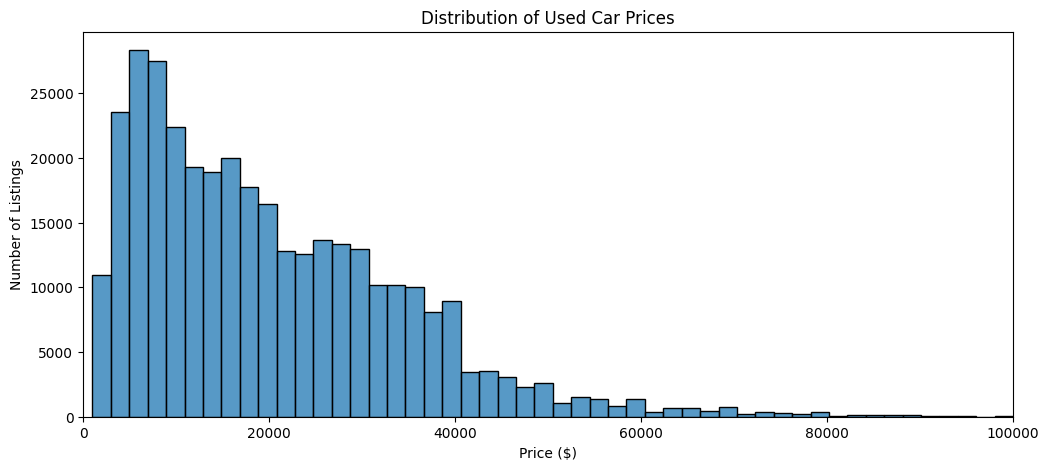

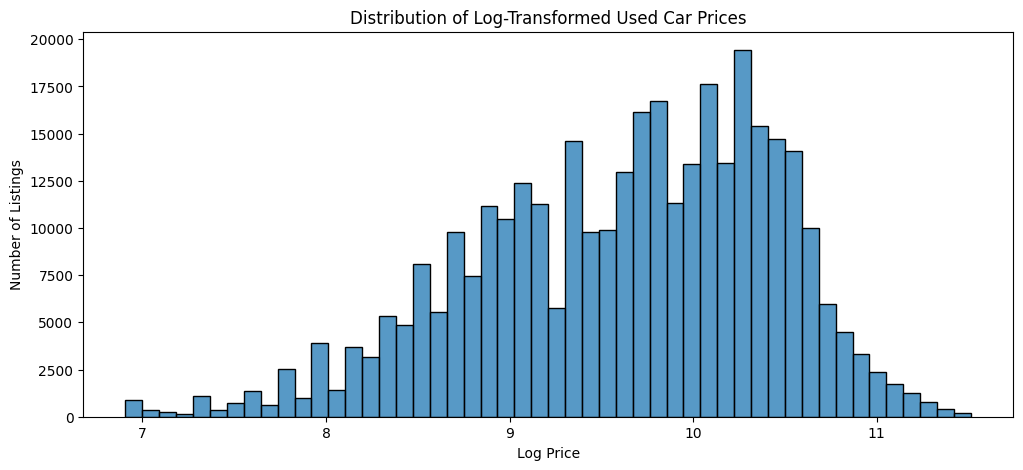

In [ ]:
# Filter out non-finite values from log_price before plotting
# Create log_price_finite to remove non-finite values in the log price column - replace with NaN or drop

import matplotlib.pyplot as plt
import numpy as np

log_price_finite = df['log_price'].replace([-np.inf, np.inf], np.nan).dropna()

# Original price distribution
plt.figure(figsize=(12, 5))
sns.histplot(df['price'], bins=50)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.xlim(0, 100000)
plt.show()

# Log-transformed price
plt.figure(figsize=(12, 5))
sns.histplot(df['log_price'], bins=50)
plt.title('Distribution of Log-Transformed Used Car Prices')
plt.xlabel('Log Price')
plt.ylabel('Number of Listings')
plt.show()

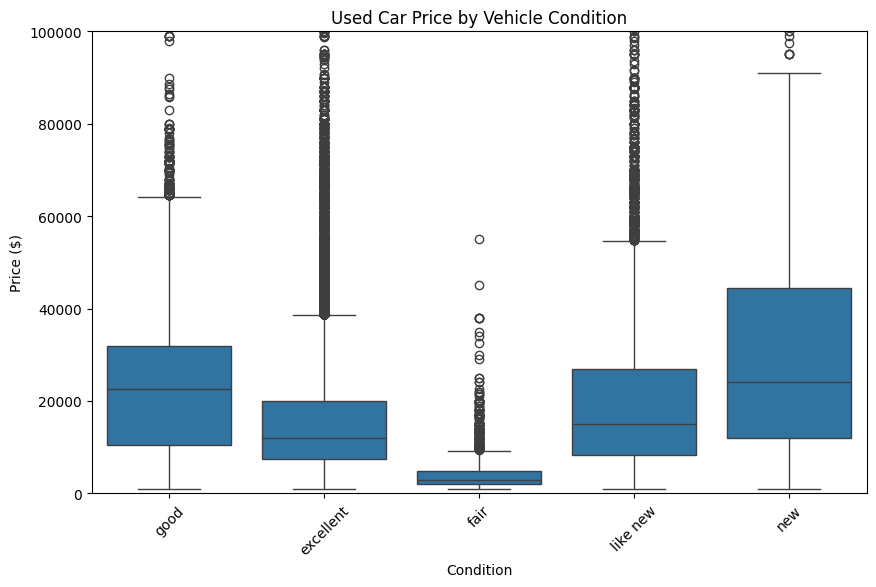

In [ ]:
# Price by Condition
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='condition', y='price')
plt.title('Used Car Price by Vehicle Condition')
plt.xlabel('Condition')
plt.ylabel('Price ($)')
plt.ylim(0, 100000)
plt.xticks(rotation=45)
plt.show()

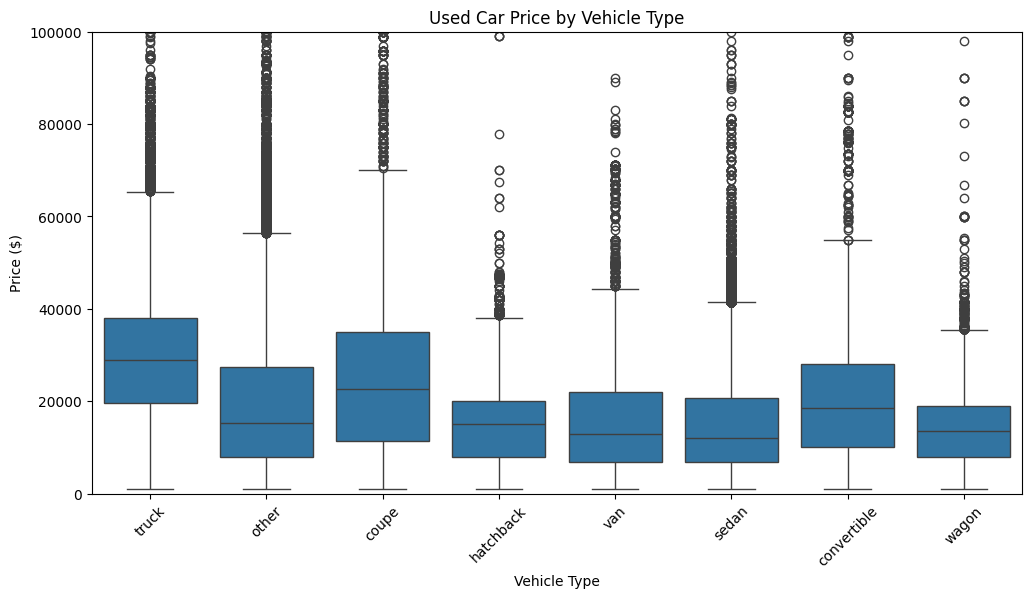

In [ ]:
# Price by Vehicle Type

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='type', y='price')
plt.title('Used Car Price by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Price ($)')
plt.ylim(0, 100000)
plt.xticks(rotation=45)
plt.show()

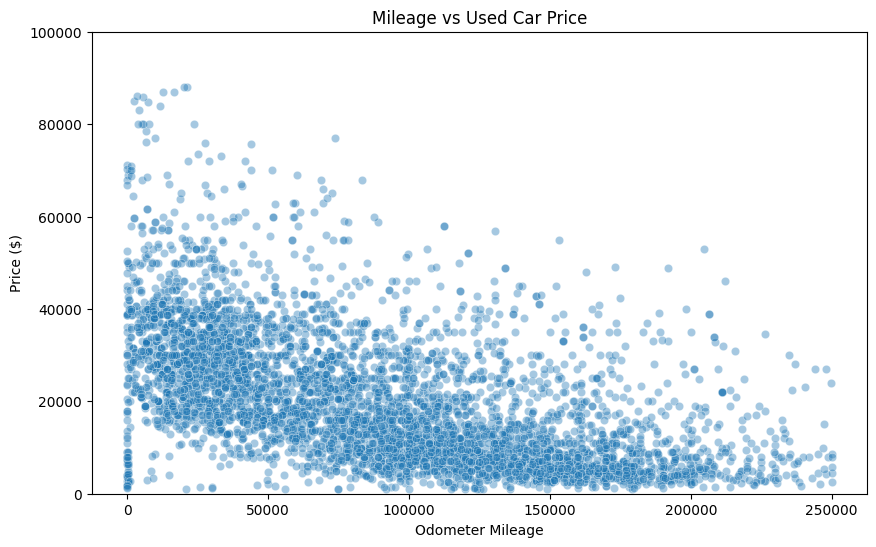

In [ ]:
# Mileage vs Price

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(5000, random_state=42), x='odometer', y='price', alpha=0.4)
plt.title('Mileage vs Used Car Price')
plt.xlabel('Odometer Mileage')
plt.ylabel('Price ($)')
plt.ylim(0, 100000)
plt.show()

In [ ]:
# convert condition to numeric

df['condition'] = df['condition'].fillna('unknown')

condition_map = {
    'salvage': 0,
    'fair': 1,
    'good': 2,
    'excellent': 3,
    'like new': 4,
    'new': 5
}

df['condition_num'] = df['condition'].map(condition_map)
df['condition_num']

,condition_num
27,2.0
28,2.0
29,2.0
30,2.0
31,3.0
...,...
426875,2.0
426876,2.0
426877,2.0
426878,2.0


In [ ]:
# Step 7: Check columns for feature selection

df.columns

Index(['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type',
       'state', 'model_family', 'is_luxury', 'cylinders_num', 'vehicle_age',
       'log_price', 'condition_num'],
      dtype='object')

In [ ]:
# Step 7: Select features for modeling

features = [
    'vehicle_age',
    'odometer',
    'manufacturer',
    'model_family',
    'condition_num',
    'cylinders_num',
    'is_luxury',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'state'
]

X = df[features]
y = df['log_price']

# Define numeric and categorical features
numeric_features = [
    'vehicle_age',
    'odometer',
    'condition_num',
    'cylinders_num',
    'is_luxury'
]

categorical_features = [
    'manufacturer',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'state'
]

In [ ]:
# Numeric pipeline: Replace missing values with the median of column and scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
# Categorical pipeline: Fill missing values with unknown and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
# Build preprocessor: scale numeric features and encode categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [ ]:
# Train-test split before modeling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Fit preprocessing only on training data

# Dynamically adjust numeric_features to only include those present in X_train
numeric_features_present_in_X_train = [
    f for f in numeric_features if f in X_train.columns
]

# Re-create preprocessor with the adjusted numeric_features
preprocessor_adjusted = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_present_in_X_train),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_prepared = preprocessor_adjusted.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_prepared = preprocessor_adjusted.transform(X_test)

In [ ]:
print(X_train.columns.tolist())

['vehicle_age', 'odometer', 'manufacturer', 'model_family', 'condition_num', 'cylinders_num', 'is_luxury', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'state']


In [ ]:
# Check final shapes before modeling

print("X_train shape:", X_train_prepared.shape)
print("X_test shape:", X_test_prepared.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (275208, 124)
X_test shape: (68802, 124)
y_train shape: (275208,)
y_test shape: (68802,)


The original dataset contained 17 columns; however, categorical variables were transformed using one-hot encoding, which expanded the feature space to 124 variables. This occurred because each category within variables such as manufacturer, model, and vehicle type became its own binary feature column.

In [ ]:
# Convert the sparse matrix to a dense array before checking for NaNs
# Note: After filling, there should ideally be no NaNs.

import numpy as np

if hasattr(X_train_prepared, 'toarray'):
    print(np.isnan(X_train_prepared.toarray()).sum())
else:
    print(np.isnan(X_train_prepared).sum())

0


In [ ]:
feature_names = preprocessor_adjusted.get_feature_names_out()

print(feature_names)

['num__vehicle_age' 'num__odometer' 'num__condition_num'
 'num__cylinders_num' 'num__is_luxury' 'cat__manufacturer_acura'
 'cat__manufacturer_alfa-romeo' 'cat__manufacturer_aston-martin'
 'cat__manufacturer_audi' 'cat__manufacturer_bmw'
 'cat__manufacturer_buick' 'cat__manufacturer_cadillac'
 'cat__manufacturer_chevrolet' 'cat__manufacturer_chrysler'
 'cat__manufacturer_dodge' 'cat__manufacturer_ferrari'
 'cat__manufacturer_fiat' 'cat__manufacturer_ford' 'cat__manufacturer_gmc'
 'cat__manufacturer_harley-davidson' 'cat__manufacturer_honda'
 'cat__manufacturer_hyundai' 'cat__manufacturer_infiniti'
 'cat__manufacturer_jaguar' 'cat__manufacturer_jeep'
 'cat__manufacturer_kia' 'cat__manufacturer_land rover'
 'cat__manufacturer_lexus' 'cat__manufacturer_lincoln'
 'cat__manufacturer_mazda' 'cat__manufacturer_mercedes-benz'
 'cat__manufacturer_mercury' 'cat__manufacturer_mini'
 'cat__manufacturer_mitsubishi' 'cat__manufacturer_morgan'
 'cat__manufacturer_nissan' 'cat__manufacturer_pontiac'
 '

**Comment**

In the data preparation phase, invalid and unrealistic records were removed, including negative prices, unrealistic model years, extreme mileage values (greater than 250,000 miles or less than 0 miles), unusually low prices less than 1000 and high prices greater than 100,000 and title status of salvage, parts only and missing. Columns with limited predictive value or excessive missing values, such as ID, VIN, paint_color, region, and size (71% of data missing) were dropped. New engineered columns like vehicle_age (engineered from the year column), is_luxury, model_family were added. Because price is often skewed, a log transformation was applied to create the target variable. Categorical variables were standardized, missing values were handled by filling with the median value, and categorical features were one-hot encoded for modeling with sklearn. Numeric variables were filled and scaled before splitting the data into training and testing sets.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

## Modeling Approach

To evaluate model performance, I used Root Mean Squared Error (RMSE) on the log-transformed vehicle price. RMSE was chosen because it provides an easy way to measure how far predictions are from actual values while placing more weight on larger errors. This is especially important in vehicle pricing, where large prediction mistakes can have a significant business impact.

The target variable was log-transformed to reduce the effect of extreme price outliers and create a more stable distribution for modeling. Because of this transformation, model errors can also be interpreted on a relative scale after converting them back to the original price values.

Four regression models were tested and compared:

1. Linear Regression to establish a baseline model
2. Ridge Regression to reduce overfitting through regularization
3. Polynomial Ridge Regression xtended Ridge Regression by adding polynomial features to capture potential nonlinear relationships between vehicle characteristics and price.
3. Lasso Regression to perform regularization and feature selection simultaneously

Cross-validation was used to evaluate model performance and grid search was used to find the best alpha values for Ridge and Lasso regression.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
# Linear Regression
# Create pipeline with preprocessing + model
from sklearn.pipeline import Pipeline

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Cross-validation
lr_scores = cross_val_score(
    lr_model, X_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print("Linear Regression RMSE:", -lr_scores.mean())

Linear Regression RMSE: 0.4025572096611164


In [ ]:
# converts the error back to the original price scale

lr_rmse = -lr_scores.mean()
lr_error_factor = np.exp(lr_rmse)

print("Linear RMSE on log price:", lr_rmse)
print("Approximate multiplicative error factor:", lr_error_factor)

Linear RMSE on log price: 0.4025572096611164
Approximate multiplicative error factor: 1.4956444880917228


In [ ]:
# Regular Ridge

# Regular numeric pipeline: no polynomial features
regular_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Regular categorical pipeline
regular_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Regular preprocessor
regular_preprocessor = ColumnTransformer(
    transformers=[
        ('num', regular_numeric_transformer, numeric_features),
        ('cat', regular_categorical_transformer, categorical_features)
    ]
)

ridge_model = Pipeline(steps=[
    ('preprocessor', regular_preprocessor),
    ('model', Ridge())
])

param_grid_ridge = {
    'model__alpha': [0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_model,
    param_grid_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

ridge_grid.fit(X_train, y_train)

print("Regular Ridge alpha:", ridge_grid.best_params_)
print("Regular Ridge RMSE:", -ridge_grid.best_score_)


Regular Ridge alpha: {'model__alpha': 10}
Regular Ridge RMSE: 0.4022546599452742


In [ ]:
# Polynomial Ridge

poly_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

poly_preprocessor = ColumnTransformer(
    transformers=[
        ('num', poly_numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

poly_ridge_model = Pipeline(steps=[
    ('preprocessor', poly_preprocessor),
    ('model', Ridge())
])

param_grid_poly_ridge = {
    'model__alpha': np.logspace(-3, 2, 10)
}

poly_ridge_grid = GridSearchCV(
    poly_ridge_model,
    param_grid_poly_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

poly_ridge_grid.fit(X_train, y_train)

print("Polynomial Ridge alpha:", poly_ridge_grid.best_params_)
print("Polynomial Ridge RMSE:", -poly_ridge_grid.best_score_)

Polynomial Ridge alpha: {'model__alpha': np.float64(7.742636826811277)}
Polynomial Ridge RMSE: 0.40251677529807306


In [ ]:
# Lasso

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

lasso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

param_grid_lasso = {
    'model__alpha': [0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    lasso_model,
    param_grid_lasso,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Lasso alpha:", lasso_grid.best_params_)
print("Lasso RMSE:", -lasso_grid.best_score_)

Lasso alpha: {'model__alpha': 0.01}
Lasso RMSE: 0.43788062059236976


In [ ]:
# Show all model results

model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Ridge Polynomial Regression', 'Lasso Regression'],
    'RMSE (Log Scale)': [
        -lr_scores.mean(),
        -ridge_grid.best_score_,
        -poly_ridge_grid.best_score_,
        -lasso_grid.best_score_
    ],
    'Original Price Scale Error Factor': [
        np.exp(-lr_scores.mean()),
        np.exp(-ridge_grid.best_score_),
        np.exp(-poly_ridge_grid.best_score_),
        np.exp(-lasso_grid.best_score_)
    ]
})

model_results

,Model,RMSE (Log Scale),Original Price Scale Error Factor
0,Linear Regression,0.402557,1.495644
1,Ridge Regression,0.402255,1.495192
2,Ridge Polynomial Regression,0.402517,1.495584
3,Lasso Regression,0.437881,1.549420


In [ ]:
best_model = ridge_grid.best_estimator_

# Train model
best_model.fit(X_train, y_train)

# Generate predictions
y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.7552455927814115


In [ ]:
# Polynomial Ridge grid search
poly_ridge_grid = GridSearchCV(
    poly_ridge_model,
    param_grid_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Train Polynomial Ridge
poly_ridge_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('poly',
                                                                                          PolynomialFeatures(include_bias=False)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['vehicle_age',
                                                                          'odometer',
                                                                          'condition_num',
                                                                          'cylinders_num',
                                                                          'is_luxury']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          Simple...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['manufacturer',
                                                                          'fuel',
                                                                          'title_status',
                                                                          'transmission',
                                                                          'drive',
                                                                          'type',
                                                                          'state'])])),
                                       ('model', Ridge())]),
             n_jobs=-1,
             param_grid={'model__alpha': array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02])},
             scoring='neg_root_mean_squared_error')

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Linear": lr_model,
    "Regular Ridge": ridge_grid.best_estimator_,
    "Polynomial Ridge": poly_ridge_grid.best_estimator_,
    "Lasso": lasso_model
}

for name, model in models.items():

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(name)
    print("RMSE:", rmse)
    print("R²:", r2)
    print()

Linear
RMSE: 0.4008778923718502
R²: 0.7559894662585604

Regular Ridge
RMSE: 0.4014884715610439
R²: 0.7552455927814115

Polynomial Ridge
RMSE: 0.40091598528047506
R²: 0.7559430904779634

Lasso
RMSE: 0.8115424100409405
R²: -1.5664074072052614e-05



**Summary**

Several regression models, including Linear Regression, Ridge Regression, Polynomial Ridge Regression, and Lasso Regression, were developed to predict used car prices. Model performance was evaluated using Root Mean Squared Error (RMSE) and R² on log-transformed price data after extensive data cleaning, outlier removal, and feature engineering.

Among the models tested, Linear Regression and Ridge Regression produced nearly identical results and significantly outperformed Lasso Regression. Linear Regression achieved the lowest RMSE overall, while Ridge Regression provided very similar predictive performance with the added benefit of regularization. Polynomial Ridge Regression also performed similarly, suggesting that additional nonlinear complexity added little improvement after preprocessing and feature engineering.

The final models achieved an RMSE of approximately 0.401 and an R² value of approximately 0.756, meaning the models explained about 76% of the variation in used car prices. These results correspond to predictions generally being within about 1.5 times the actual vehicle price.

Lasso Regression performed substantially worse, likely because its feature selection process removed variables that still contained important predictive information. Overall, the results demonstrate that data cleaning, outlier filtering, and feature engineering contributed more to model performance than increasing model complexity.



### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

The goal of this project was to identify the key factors influencing used car prices and to build a reliable predictive pricing model. The final results indicate that preprocessing and feature engineering were critical to improving model performance. Removing unrealistic listings, filtering out salvage and problematic vehicles, handling missing values, and reducing noisy categories significantly improved both RMSE and R² compared to the initial baseline models.

Feature analysis suggests that vehicle age, odometer reading, manufacturer, model, condition, and vehicle type were among the most influential predictors of price. Luxury vehicle indicators and certain truck or SUV categories were associated with higher prices, while older vehicles, higher mileage, and lower condition ratings were associated with lower prices.

Although Ridge Regression provided slight regularization benefits, the near-identical performance between Linear Regression and Ridge Regression suggests that the cleaned dataset had relatively stable relationships and limited overfitting. This indicates that the quality of the data preparation process played a larger role in model success than the complexity of the regression algorithm itself.

Overall, the final regression models demonstrated strong predictive performance for a real-world marketplace dataset and provided interpretable insights into the main drivers of used car pricing.


**Feature Importance Analysis**

Analysis of the regression model coefficients showed that several features had a strong influence on used car prices. Higher prices were generally associated with newer vehicles, lower mileage, luxury brands, and certain truck or SUV vehicle types. In contrast, older vehicles, higher odometer readings, and poorer vehicle condition were associated with lower prices.

Vehicle manufacturer, model, condition, and mileage were among the most influential predictors in the final models. While some highly specific model-level features captured strong pricing effects, broader patterns such as vehicle age, brand, vehicle type, and condition provided the most meaningful and actionable insights for understanding pricing trends in the used car market.

In [158]:
best_model = ridge_grid.best_estimator_
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_model.named_steps['model'].coef_

import pandas as pd

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df.sort_values(by='coefficient', ascending=False).head(20)

,feature,coefficient
15,cat__manufacturer_ferrari,0.781165
47,cat__fuel_diesel,0.553130
42,cat__manufacturer_tesla,0.362950
37,cat__manufacturer_porsche,0.338032
39,cat__manufacturer_rover,0.305053
65,cat__type_convertible,0.213051
6,cat__manufacturer_alfa-romeo,0.193576
43,cat__manufacturer_toyota,0.184672
5,cat__manufacturer_acura,0.178630
70,cat__type_truck,0.163927


Analysis of the Ridge Regression coefficients showed that vehicle manufacturer, vehicle type, drivetrain, and engine-related features had some of the strongest influences on predicted prices. Luxury and specialty brands such as Ferrari, Tesla, Porsche, and Alfa Romeo were strongly associated with higher vehicle prices. Truck-related features, including truck body types, four-wheel drive, diesel fuel, and higher cylinder counts, also had positive relationships with price.

Several premium and utility-focused manufacturers, including Toyota, GMC, Lincoln, Infiniti, and Ram, were associated with higher predicted prices as well. Features related to luxury vehicles and performance characteristics generally increased predicted values, while older vehicles, higher mileage, and lower condition ratings were associated with lower prices in the model.

Overall, the feature importance analysis suggests that brand reputation, vehicle capability, condition, and utility-related characteristics were among the most important drivers of used car pricing in the dataset.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Key Findings and Recommendations

### Key Findings

1. Mileage is a major price driver. Vehicles with lower odometer readings generally sell for higher prices.
2. Newer vehicles command higher resale value. Vehicle age is negatively associated with price.
3. Condition matters. Cars in better condition tend to have higher predicted prices.
4. Manufacturer and vehicle type affect pricing. Luxury brands, trucks, SUVs, and specialty vehicles often command higher prices.
5. Extreme and noisy records reduce model quality. Removing invalid prices, salvage vehicles, extreme mileage, and unrealistic years improved the reliability of the analysis.

### Business Recommendations

1. Prioritize newer, low-mileage inventory. These vehicles are more likely to retain value and support stronger resale pricing.
2. Stock high-demand vehicle types. SUVs and trucks should be prioritized because they tend to show stronger resale potential.
3. Use caution with high-mileage or salvage vehicles. These vehicles should be discounted or evaluated separately.
4. Use model results as pricing guidance, not exact predictions. The model captures broad pricing patterns but should be combined with local market knowledge.
5. Collect additional data for better predictions.Accident history, ownership history, maintenance records, and regional demand could improve future model accuracy.

### Next Steps

Future improvements could include adding more detailed vehicle history information, such as accident records, number of previous owners, maintenance history, and trim level details. Including these factors could help improve the accuracy of price predictions and provide better guidance for pricing decisions.